# Community Area Feature Visualization Pipeline

Reads `02_merged_data_full.parquet` or `02_merged_data_sample_10pct.parquet`, assigns each trip to one of Chicago's 77 **community areas** (via `pickup_community_area` / `dropoff_community_area`), and visualises trip-count and feature distributions per community area.

Community-area boundaries come from `chicago_community_boundaries.json`. All maps are **matplotlib / geopandas** choropleths drawn side by side: **Pickup (left)** and **Dropoff (right)**.

In [15]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import geopandas

## Load data

Load only the columns needed for the community-area analysis. `trip_seconds` is stored as a duration, so we convert it to total seconds for aggregation.

In [16]:
_BASE_COLS = [
    "pickup_community_area", "dropoff_community_area",
    "trip_start", "trip_end", "hour", "day_of_week", "is_weekend",
    "BankHoliday", "CorporateHoliday", "CityHoliday", "StateHoliday",
]
_FEATURE_COLS = [
    "fare_usd", "tips_usd", "tolls_usd", "extras_usd", "trip_total_usd",
    "trip_miles", "trip_seconds", "average_speed_mph",
    "temperature_c", "temperature_max_c", "temperature_min_c",
    "rain", "strong_rain", "snow", "wind", "strong_wind"
]

df = (
    pl.read_parquet("../data/02/02_merged_data.parquet", columns=_BASE_COLS + _FEATURE_COLS)
    .with_columns(pl.col("trip_seconds").dt.total_seconds().alias("trip_seconds"))
    .to_pandas()
)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Shape: 109,085 rows x 27 columns


,pickup_community_area,dropoff_community_area,trip_start,trip_end,hour,day_of_week,is_weekend,BankHoliday,CorporateHoliday,CityHoliday,...,trip_seconds,average_speed_mph,temperature_c,temperature_max_c,temperature_min_c,rain,strong_rain,snow,wind,strong_wind
0,8,8.0,2024-10-01 00:00:00-05:00,2024-10-01 00:06:00-05:00,0,2,False,0,0,0,...,360,13.000000,17.9,19.15,13.55,0,0,0,1,0
1,56,NaN,2024-10-01 00:45:00-05:00,2024-10-01 00:55:12-05:00,0,2,False,0,0,0,...,612,24.294118,17.9,19.15,13.55,0,0,0,1,0
2,32,38.0,2024-10-01 00:45:00-05:00,2024-10-01 01:03:00-05:00,0,2,False,0,0,0,...,1080,19.000000,17.9,19.15,13.55,0,0,0,1,0


## Load community-area boundaries

Build a `GeoDataFrame` of the 77 community areas, keyed by `area_number` (matches `pickup_community_area` / `dropoff_community_area` in the trip data).

In [17]:
communities_gdf = geopandas.read_file("../data/00/chicago_community_boundaries.json")
communities_gdf["area_number"] = communities_gdf["area_numbe"].astype(int)
communities_gdf["community"] = communities_gdf["community"].str.title()
communities_gdf = communities_gdf[["area_number", "community", "geometry"]].set_crs("EPSG:4326")

print(f"{len(communities_gdf)} community areas loaded")
communities_gdf.head(3)

77 community areas loaded


,area_number,community,geometry
0,35,Douglas,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,36,Oakland,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,37,Fuller Park,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."


## Aggregation & plotting helpers

In [18]:
def _community_aggregate(df_subset, trip_type, feature=None):
    """Aggregate df_subset by community area.
    trip_type is 'pickup' or 'dropoff'.
    Returns [area_number, trip_count] or [area_number, mean_val, trip_count].
    """
    col = f"{trip_type}_community_area"
    sub = df_subset.dropna(subset=[col] + ([feature] if feature else []))
    if feature:
        agg = sub.groupby(col)[feature].agg(["mean", "count"]).reset_index()
        agg.columns = ["area_number", "mean_val", "trip_count"]
    else:
        agg = sub[col].value_counts().reset_index()
        agg.columns = ["area_number", "trip_count"]
    agg["area_number"] = agg["area_number"].astype(int)
    return agg


def _row_geo(sub_pickup, sub_dropoff, kind, feature):
    """Return [pickup_gdf, dropoff_gdf] for one row, with the value column merged on.

    Community areas with no trips are left as NaN (not filled with 0) so they can be
    drawn explicitly in white via missing_kwds, rather than appearing as the pale
    low end of the colour gradient.
    """
    gs = []
    for subset, trip_type in ((sub_pickup, "pickup"), (sub_dropoff, "dropoff")):
        agg = _community_aggregate(subset, trip_type, feature if kind == "mean" else None)
        g = communities_gdf.merge(agg, on="area_number", how="left")
        gs.append(g)
    return gs


def _value_range(gdfs, value_col, force_zero_min):
    vals = np.concatenate([g[value_col].to_numpy(dtype="float64") for g in gdfs])
    vals = vals[~np.isnan(vals)]
    if vals.size == 0:
        return 0.0, 1.0
    lo = 0.0 if force_zero_min else float(vals.min())
    hi = float(vals.max())
    return lo, (hi if hi > lo else lo + 1)


# One consistent gradient for every trip-count map; the feature maps keep their own (blue) gradient.
# Community areas with no trips are always drawn in white.
COUNT_CMAP = "YlOrRd"
FEATURE_CMAP = "PuBuGn"
NO_TRIPS_COLOR = "white"


def plot_community_grid(items, kind="count", cmap=COUNT_CMAP, suptitle="",
                        shared_scale=True, cbar_label=None, row_height=3.8):
    """Plot a stacked grid of Pickup (left) / Dropoff (right) choropleths.

    items: list of (label, sub_pickup, sub_dropoff, feature). For counts pass
           feature=None; sub_pickup/sub_dropoff are usually the same dataframe
           except for hour-of-day, where they are filtered by pickup vs dropoff time.
    kind:  'count' (uses trip_count) or 'mean' (uses mean_val of `feature`).

    Community areas with no trips are rendered in white (NO_TRIPS_COLOR) with a thin
    grey border so empty areas are still visible.
    """
    value_col = "trip_count" if kind == "count" else "mean_val"
    force_zero = kind == "count"

    rows = [(label, _row_geo(sp, sd, kind, feat)) for label, sp, sd, feat in items]

    if shared_scale:
        gvmin, gvmax = _value_range([g for _, gs in rows for g in gs], value_col, force_zero)

    def _label(lbl):
        return cbar_label(lbl) if callable(cbar_label) else cbar_label

    n = len(rows)
    fig, axes = plt.subplots(n, 2, figsize=(11, row_height * n),
                             squeeze=False, constrained_layout=True)

    for i, (label, gs) in enumerate(rows):
        vmin, vmax = (gvmin, gvmax) if shared_scale else _value_range(gs, value_col, force_zero)
        for j, g in enumerate(gs):
            ax = axes[i][j]
            g.plot(column=value_col, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                   edgecolor="0.6", linewidth=0.3,
                   missing_kwds={"color": NO_TRIPS_COLOR, "edgecolor": "0.6",
                                 "linewidth": 0.3, "label": "no trips"})
            side = "Pickup" if j == 0 else "Dropoff"
            ax.set_title(f"{side} — {label}", fontsize=10)
            ax.set_axis_off()
        if not shared_scale:
            sm = ScalarMappable(norm=Normalize(vmin, vmax), cmap=cmap)
            sm.set_array([])
            cb = fig.colorbar(sm, ax=list(axes[i]), fraction=0.046, pad=0.02)
            if cbar_label is not None:
                cb.set_label(_label(label))

    if shared_scale:
        sm = ScalarMappable(norm=Normalize(gvmin, gvmax), cmap=cmap)
        sm.set_array([])
        cb = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
        if cbar_label is not None:
            cb.set_label(_label(None))

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.show()

## Map: trip count per community area

Number of trips per community area, **Pickup (left)** vs **Dropoff (right)**, community areas with **no trips are drawn in white**.

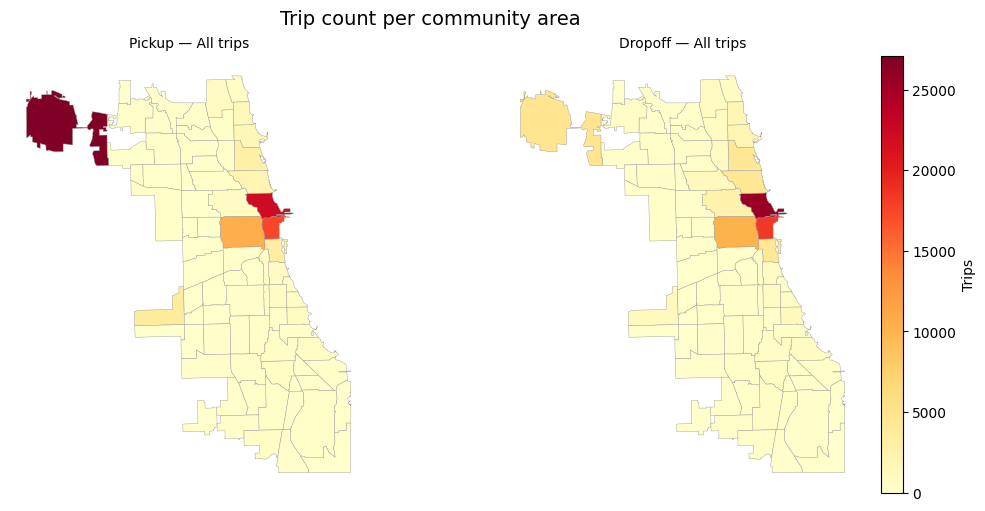

In [ ]:
#| label: fig-demand-spatial
#| fig-cap: "Trips per community area, pickup (left) vs dropoff (right), shared scale. Two poles dominate: O'Hare (far north-west) and the downtown lakefront"
plot_community_grid(
    [("All trips", df, df, None)],
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trip count per community area",
    shared_scale=True, cbar_label="Trips",
    row_height=5.0,
)

## Maps: mean feature value per community area

One row per numeric feature; **Pickup (left)** vs **Dropoff (right)**. Community areas with no trips are shown in **white**.

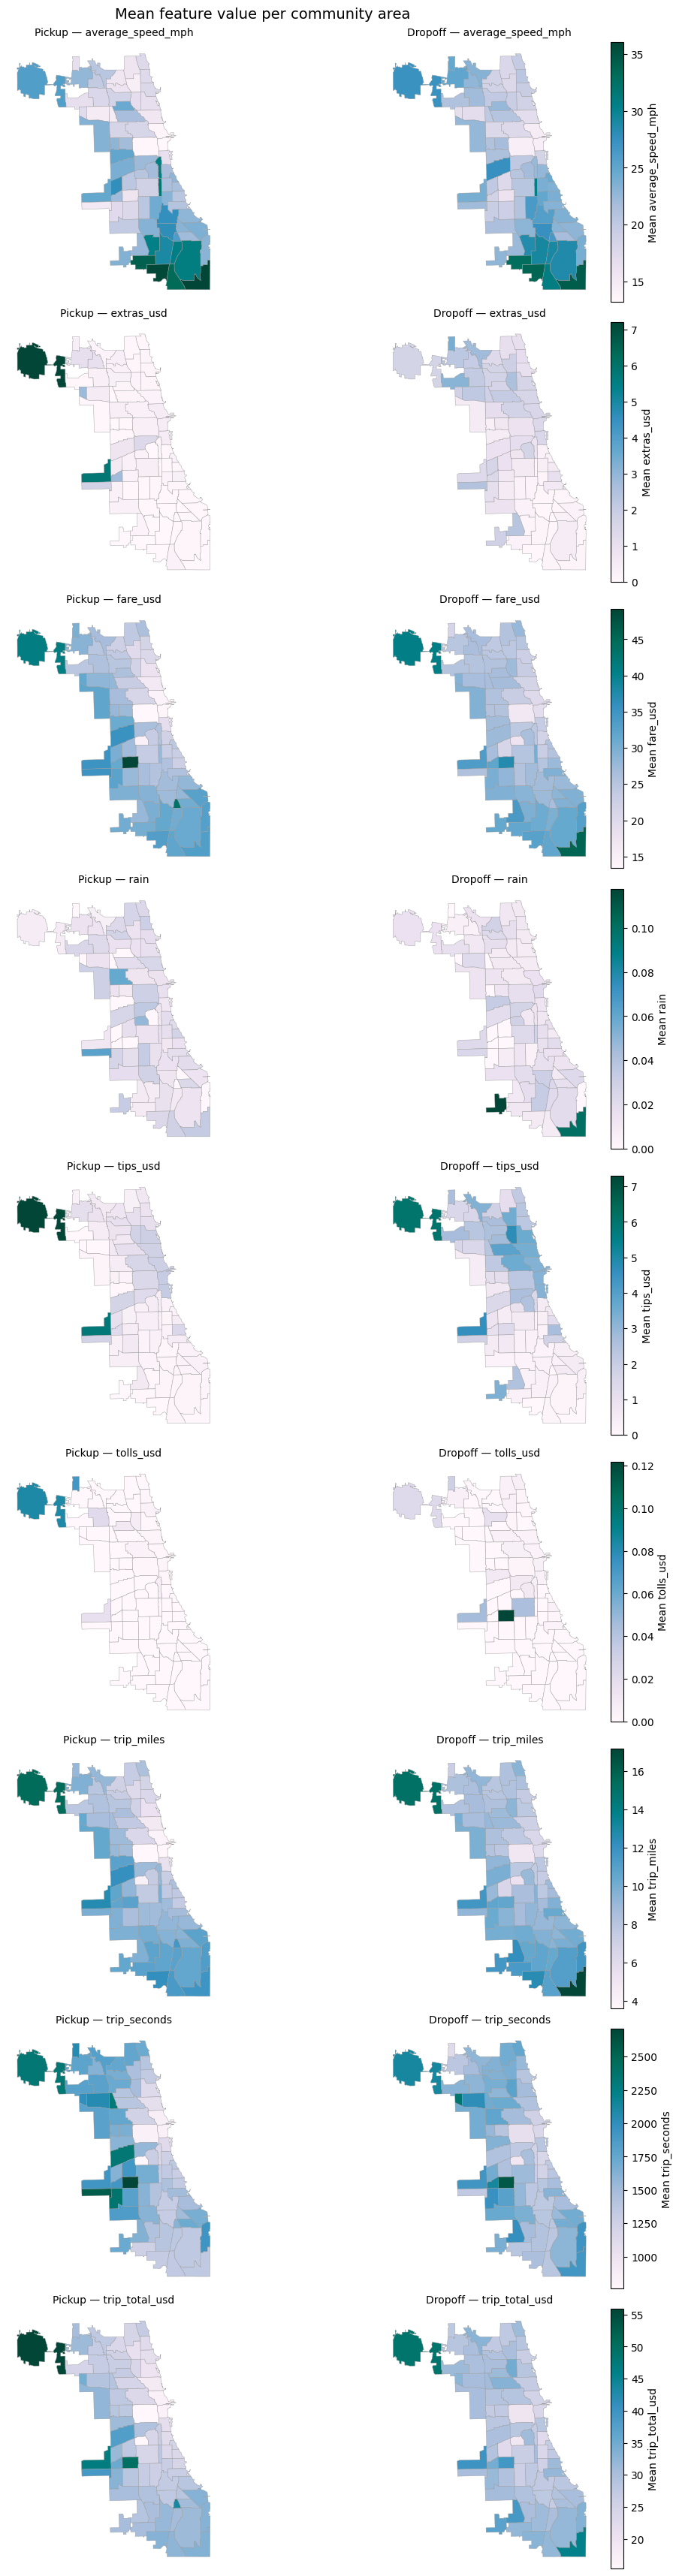

In [ ]:
#| label: fig-feature-grid
#| fig-cap: "Mean value of all 19 numeric features per community area, pickup (left) vs dropoff (right), each feature on its own scale."
SELECTABLE_FEATURES = [
    "apparent_temperature", "average_speed_mph", "extras_usd", "fare_usd",
    "precipitation", "rain", "relative_humidity_2m", "snow_depth",
    "temperature_2m", "temperature_2m_max", "temperature_2m_min",
    "tips_usd", "tolls_usd", "trip_miles", "trip_seconds", "trip_total_usd",
    "wind_direction_10m", "wind_gusts_10m", "wind_speed_10m",
]
SELECTABLE_FEATURES = [f for f in SELECTABLE_FEATURES if f in df.columns]

plot_community_grid(
    [(feat, df, df, feat) for feat in SELECTABLE_FEATURES],
    kind="mean", cmap=FEATURE_CMAP,
    suptitle="Mean feature value per community area",
    shared_scale=False,
    cbar_label=lambda feat: f"Mean {feat}",
)

### Summary: the distance-to-core gradient

The full feature grid above is comprehensive but too dense for the main report, and it mixes two kinds of feature: **weather**, which is essentially uniform across the city (it is a temporal, not a spatial, signal), and **trip economics**, which varies strongly in space. This row keeps only three trip-economics features that tell one coherent story: mean fare, mean trip distance and mean speed. They show how trip value and length grow with distance from the centre while speed drops in the congested core.

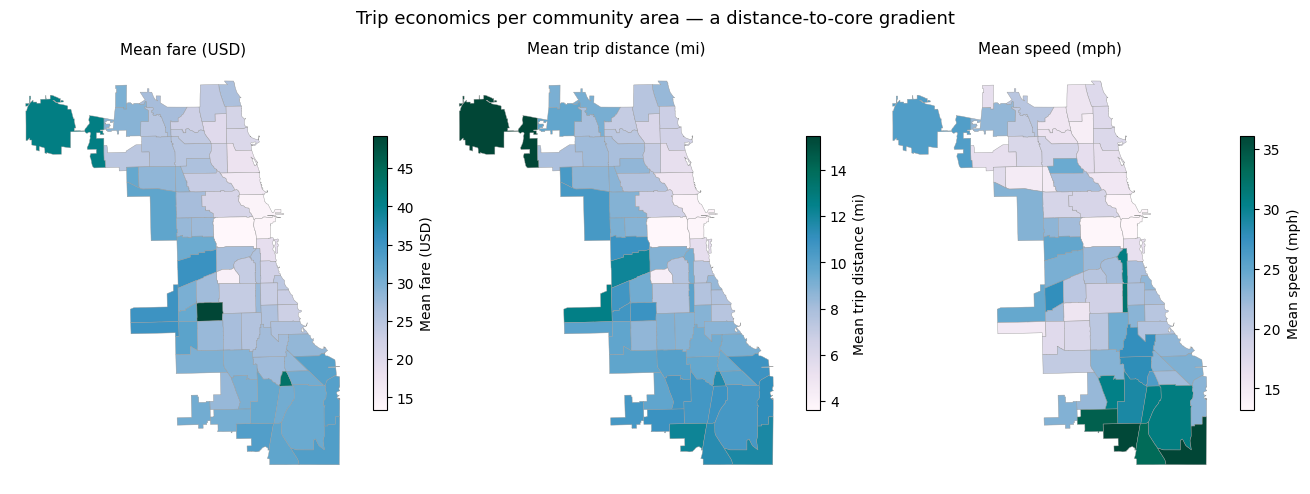

In [ ]:
#| label: fig-feature-gradient
#| fig-cap: "Three trip-economics features per community area (pickup aggregation): mean fare, mean trip distance and mean speed."

_CURATED = [("fare_usd", "Mean fare (USD)"),
            ("trip_miles", "Mean trip distance (mi)"),
            ("average_speed_mph", "Mean speed (mph)")]

fig, axes = plt.subplots(1, 3, figsize=(13, 5), constrained_layout=True)
for ax, (feat, title) in zip(axes, _CURATED):
    agg = _community_aggregate(df, "pickup", feat)
    g = communities_gdf.merge(agg, on="area_number", how="left")
    g.plot(column="mean_val", ax=ax, cmap=FEATURE_CMAP,
           edgecolor="0.6", linewidth=0.3, legend=True,
           legend_kwds={"shrink": 0.6, "label": title},
           missing_kwds={"color": NO_TRIPS_COLOR, "edgecolor": "0.6",
                         "linewidth": 0.3, "label": "no trips"})
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

fig.suptitle("Trip economics per community area — a distance-to-core gradient", fontsize=13)
plt.show()

## Maps: trips per community area by day of week

One row per weekday; **Pickup (left)** vs **Dropoff (right)**. All days share a colour scale so volumes are comparable across days. `day_of_week` encodes 1 = Monday … 7 = Sunday.

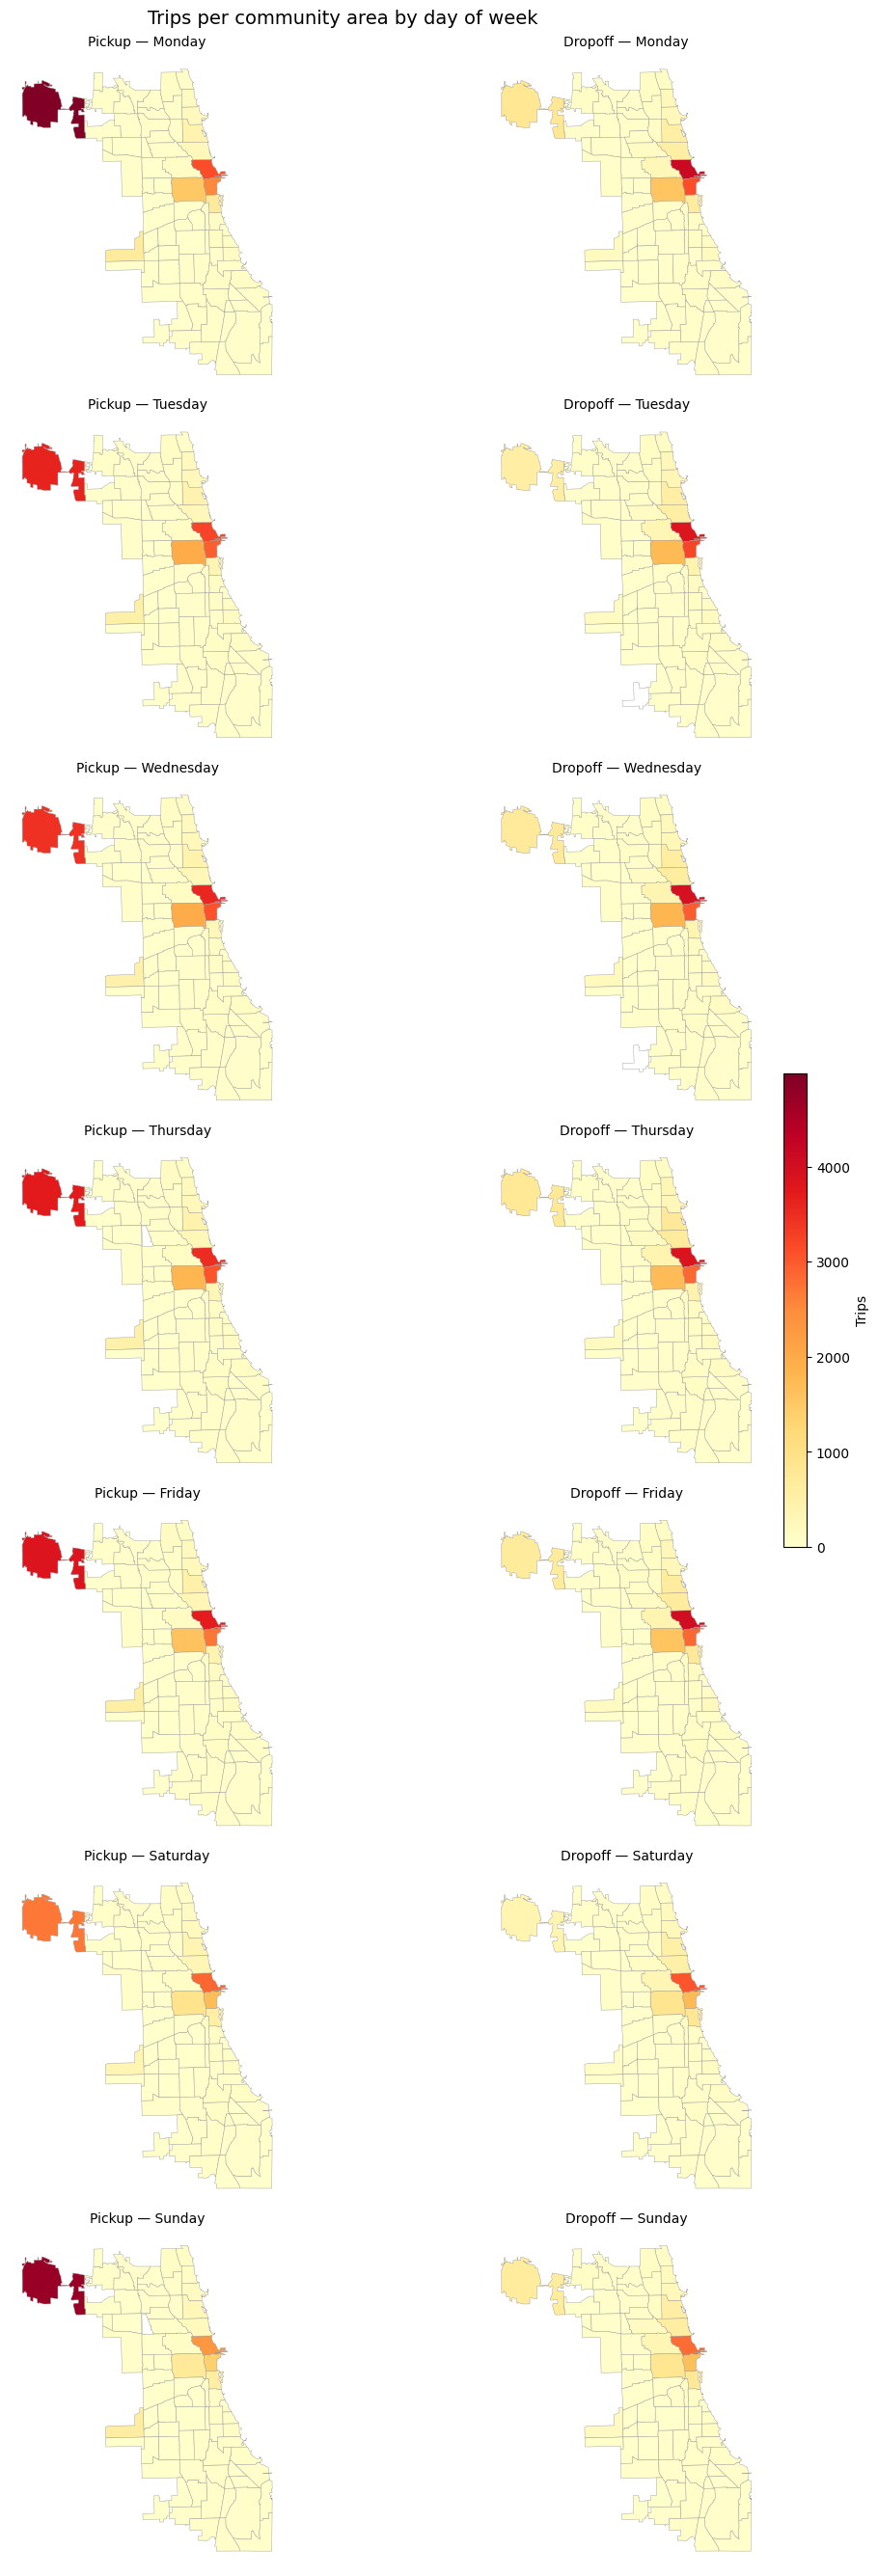

In [ ]:
#| label: fig-dow-demand
#| fig-cap: "Trips per community area by day of week, pickup (left) vs dropoff (right), shared scale."
_DOW_NAMES = {
    1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday",
    5: "Friday", 6: "Saturday", 7: "Sunday",
}

_dow_items = [
    (name, df[df["day_of_week"] == i], df[df["day_of_week"] == i], None)
    for i, name in _DOW_NAMES.items()
]

plot_community_grid(
    _dow_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by day of week",
    shared_scale=True, cbar_label="Trips",
)

## Maps: trips per community area by hour of day

One row per hour (00–23); **Pickup (left)** vs **Dropoff (right)**. Pickup maps are filtered by pickup hour, dropoff maps by dropoff hour. All hours share a colour scale.

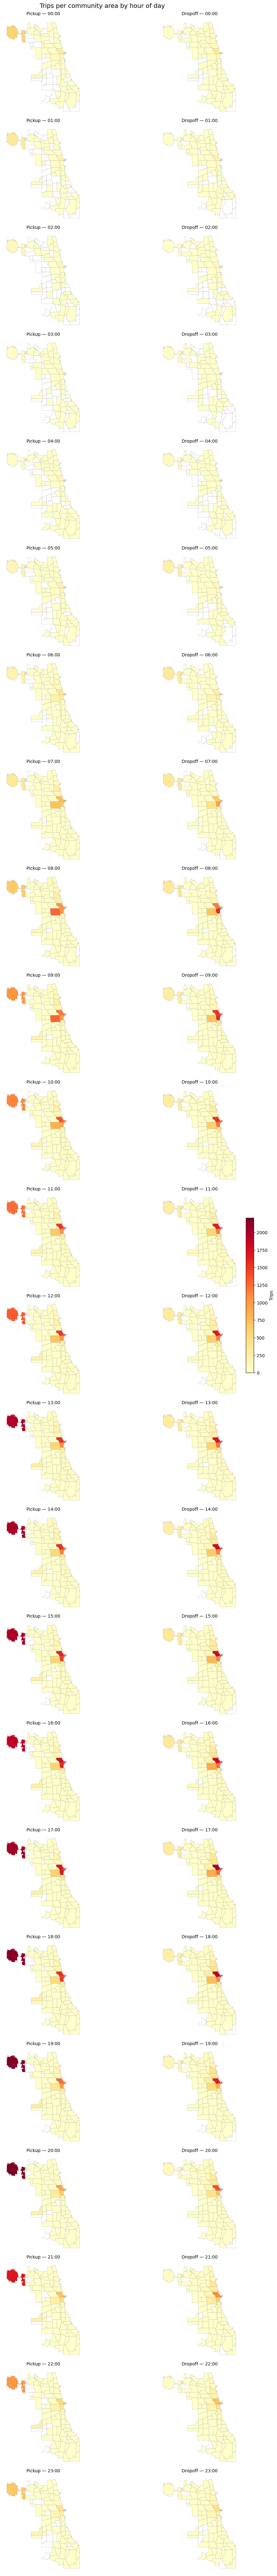

In [23]:
_dropoff_hour = df["trip_end"].dt.hour

_hour_items = [
    (f"{h:02d}:00", df[df["hour"] == h], df[_dropoff_hour == h], None)
    for h in range(24)
]

plot_community_grid(
    _hour_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by hour of day",
    shared_scale=True, cbar_label="Trips",
    row_height=3.4,
)

### Summary: taxi demand by hour of day

The 24-row map above is exhaustive but hard to read at a glance. Here we collapse the spatial dimension and keep the temporal one: total pickups and dropoffs per hour across the whole city. This makes the dayly cycle legible in a single plot with a near-empty night, a steep morning ramp and a 17:00 evening peak. The pickup and dropoff curves almost overlap; the tiny gap (pickups slightly ahead while demand rises, dropoffs slightly ahead while it falls) is just trip duration pushing dropoffs into later hours, not a strong directional commuting pattern.

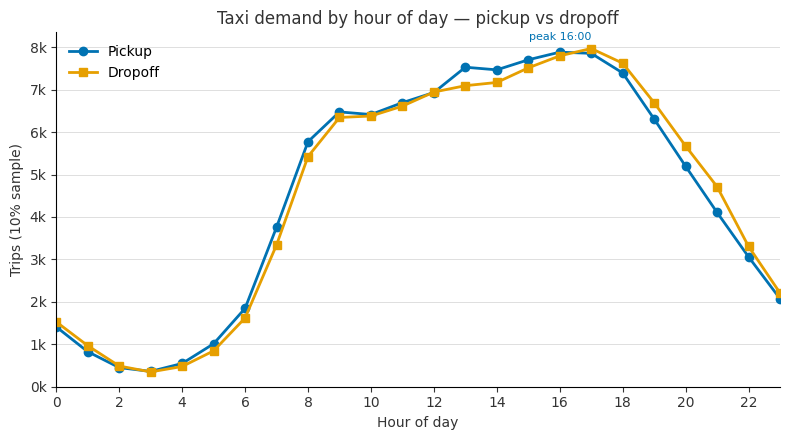

In [ ]:
#| label: fig-hourly-demand
#| fig-cap: "Total taxi trips by hour of day, split by pickup time vs dropoff time."
from matplotlib.ticker import FuncFormatter

# Compact summary of the 24-row hour-of-day maps above: collapse space, keep time.
_pickup_by_hour = df["hour"].value_counts().reindex(range(24), fill_value=0).sort_index()
_dropoff_by_hour = (df["trip_end"].dt.hour
                    .value_counts().reindex(range(24), fill_value=0).sort_index())

# Okabe-Ito blue / orange: a colourblind-safe categorical pair. Marker shape is a
# second, redundant identity cue so the two series never rely on colour alone.
C_PICKUP, C_DROPOFF, INK = "#0072B2", "#E69F00", "#333333"
hours = list(range(24))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hours, _pickup_by_hour.values, color=C_PICKUP, lw=2, marker="o",
        markersize=6, label="Pickup")
ax.plot(hours, _dropoff_by_hour.values, color=C_DROPOFF, lw=2, marker="s",
        markersize=6, label="Dropoff")

# One selective callout: the evening pickup peak (the number that matters most).
_peak_h = int(np.asarray(_pickup_by_hour.values).argmax())
_peak_v = int(np.asarray(_pickup_by_hour.values).max())
ax.annotate(f"peak {_peak_h:02d}:00", (_peak_h, _peak_v), color=C_PICKUP,
            fontsize=8, xytext=(0, 9), textcoords="offset points", ha="center")

ax.set_xlim(0, 23)
ax.set_ylim(bottom=0)
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day", color=INK)
ax.set_ylabel("Trips (10% sample)", color=INK)
ax.set_title("Taxi demand by hour of day — pickup vs dropoff", color=INK)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.grid(axis="y", color="0.85", linewidth=0.6)
ax.set_axisbelow(True)
for _spine in ("top", "right"):
    ax.spines[_spine].set_visible(False)
ax.tick_params(colors=INK)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

## Maps: trips per community area by 8-hour block

One row per 8-hour block (00–07, 08–15, 16–23); **Pickup (left)** vs **Dropoff (right)**. Pickup maps use pickup time, dropoff maps use dropoff time. Blocks share a colour scale.

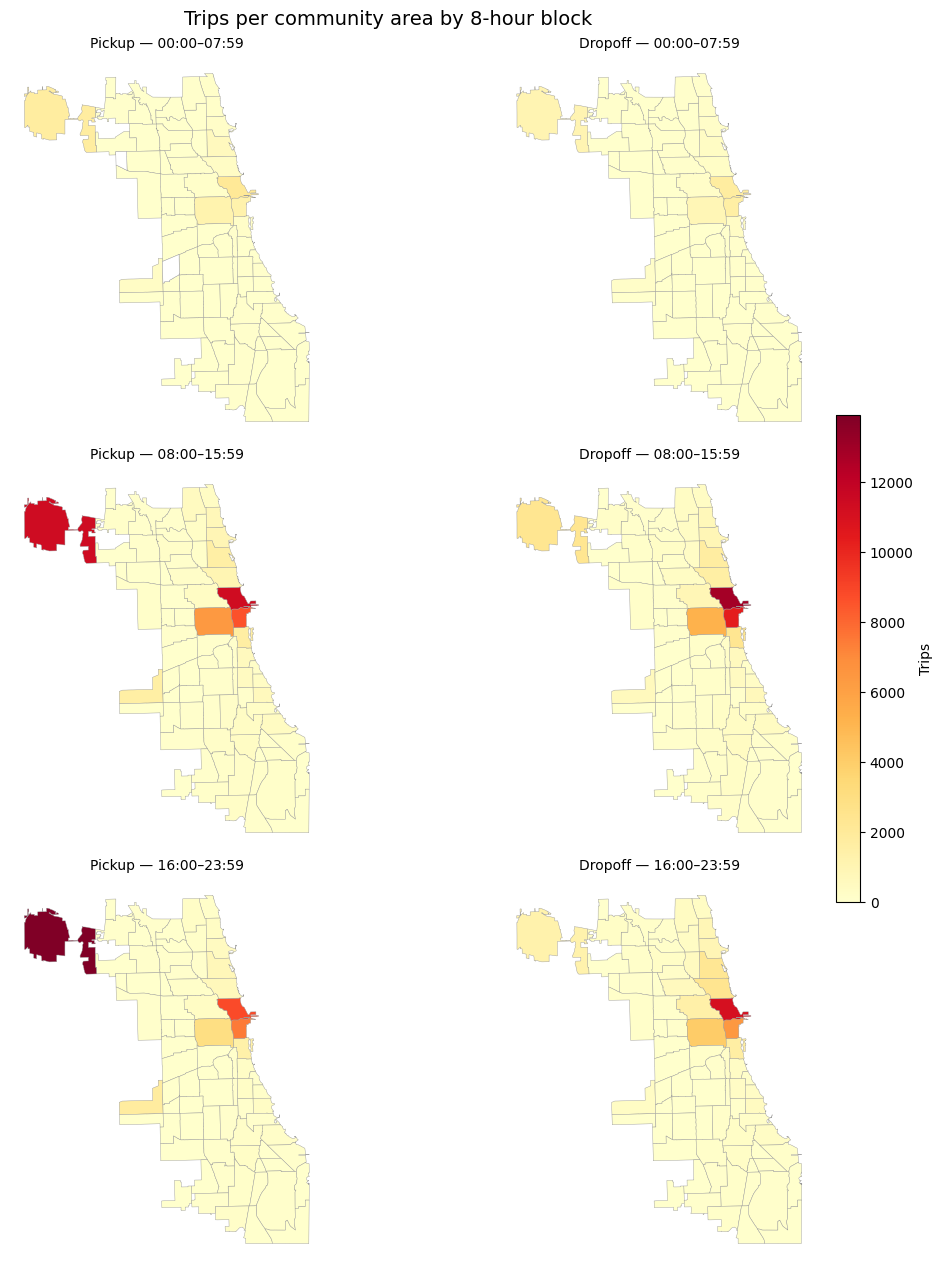

In [ ]:
#| label: fig-block-demand
#| fig-cap: "Trips per community area by 8-hour block, pickup (left) vs dropoff (right), shared scale."
_dropoff_block = df["trip_end"].dt.hour // 8
_BLOCK_LABELS = {0: "00:00–07:59", 1: "08:00–15:59", 2: "16:00–23:59"}

_block_items = [
    (label, df[_pickup_block == b], df[_dropoff_block == b], None)
    for b, label in _BLOCK_LABELS.items()
]

plot_community_grid(
    _block_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by 8-hour block",
    shared_scale=True, cbar_label="Trips",
    row_height=4.2,
)

## Maps: trips per community area by month

One row per month present in the data; **Pickup (left)** vs **Dropoff (right)**. Pickup maps are filtered by pickup month (`trip_start`), dropoff maps by dropoff month (`trip_end`). Community areas with no trips are drawn in white.

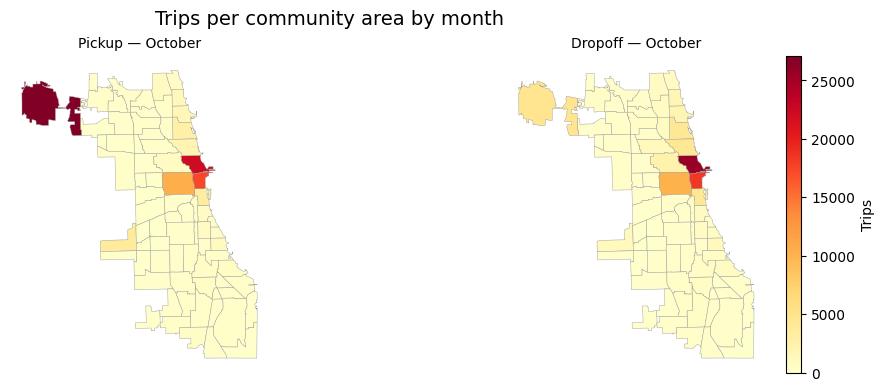

In [26]:
#| label: fig-month-demand
#| fig-cap: "Trips per community area by month, pickup (left) vs dropoff (right), shared scale. The spatial structure is constant all year; volume varies seasonally, with December the lightest month."
import calendar

_pickup_month = df["trip_start"].dt.month
_dropoff_month = df["trip_end"].dt.month
_months = sorted(_pickup_month.dropna().unique())

_month_items = [
    (calendar.month_name[int(m)], df[_pickup_month == m], df[_dropoff_month == m], None)
    for m in _months
]

plot_community_grid(
    _month_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by month",
    shared_scale=True, cbar_label="Trips",
)

### Summary: taxi demand by month

The by-month map above is comprehensive but hard to compare at a glance. Here we collapse the spatial dimension and keep the temporal one: total pickups and dropoffs per month across the whole city. This makes the seasonal cycle legible in a single plot, quantifying the December low already visible in the map above.

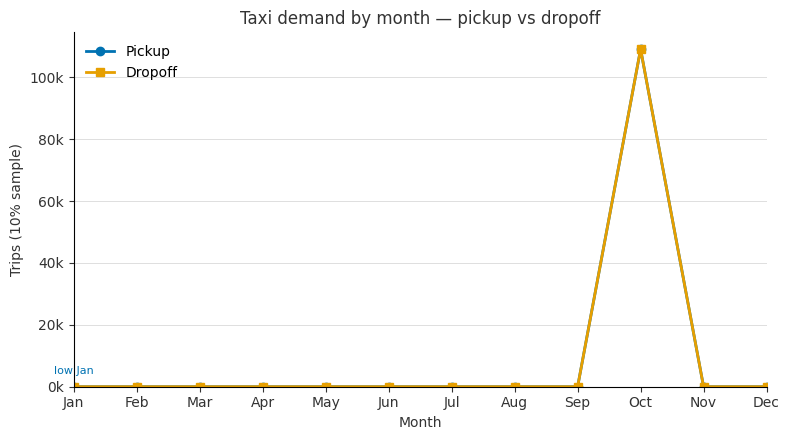

In [ ]:
#| label: fig-monthly-demand
#| fig-cap: "Total taxi trips by month, split by pickup time vs dropoff time."
import calendar
from matplotlib.ticker import FuncFormatter

# Compact summary of the by-month maps above: collapse space, keep time.
_pickup_by_month = (df["trip_start"].dt.month
                     .value_counts().reindex(range(1, 13), fill_value=0).sort_index())
_dropoff_by_month = (df["trip_end"].dt.month
                      .value_counts().reindex(range(1, 13), fill_value=0).sort_index())

C_PICKUP, C_DROPOFF, INK = "#0072B2", "#E69F00", "#333333"
months = list(range(1, 13))
month_labels = [calendar.month_abbr[m] for m in months]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(months, _pickup_by_month.values, color=C_PICKUP, lw=2, marker="o",
        markersize=6, label="Pickup")
ax.plot(months, _dropoff_by_month.values, color=C_DROPOFF, lw=2, marker="s",
        markersize=6, label="Dropoff")

# One selective callout: the seasonal low (the number the main text calls out).
_low_i = int(np.asarray(_pickup_by_month.values).argmin())
_low_m, _low_v = months[_low_i], int(_pickup_by_month.values[_low_i])
ax.annotate(f"low {calendar.month_abbr[_low_m]}", (_low_m, _low_v), color=C_PICKUP,
            fontsize=8, xytext=(0, 9), textcoords="offset points", ha="center")

ax.set_xlim(1, 12)
ax.set_ylim(bottom=0)
ax.set_xticks(months)
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month", color=INK)
ax.set_ylabel("Trips (10% sample)", color=INK)
ax.set_title("Taxi demand by month — pickup vs dropoff", color=INK)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax.grid(axis="y", color="0.85", linewidth=0.6)
ax.set_axisbelow(True)
for _spine in ("top", "right"):
    ax.spines[_spine].set_visible(False)
ax.tick_params(colors=INK)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


## Maps: trips per community area by holiday type

One row per holiday type; **Pickup (left)** vs **Dropoff (right)**. Each trip carries four 0/1 holiday flags (`BankHoliday`, `CorporateHoliday`, `CityHoliday`, `StateHoliday`); a row keeps only the trips where that flag is set. Because holiday days are a small slice of the data, the holiday types differ greatly in total volume, so each row uses its **own** colour scale. Community areas with no trips are drawn in white.

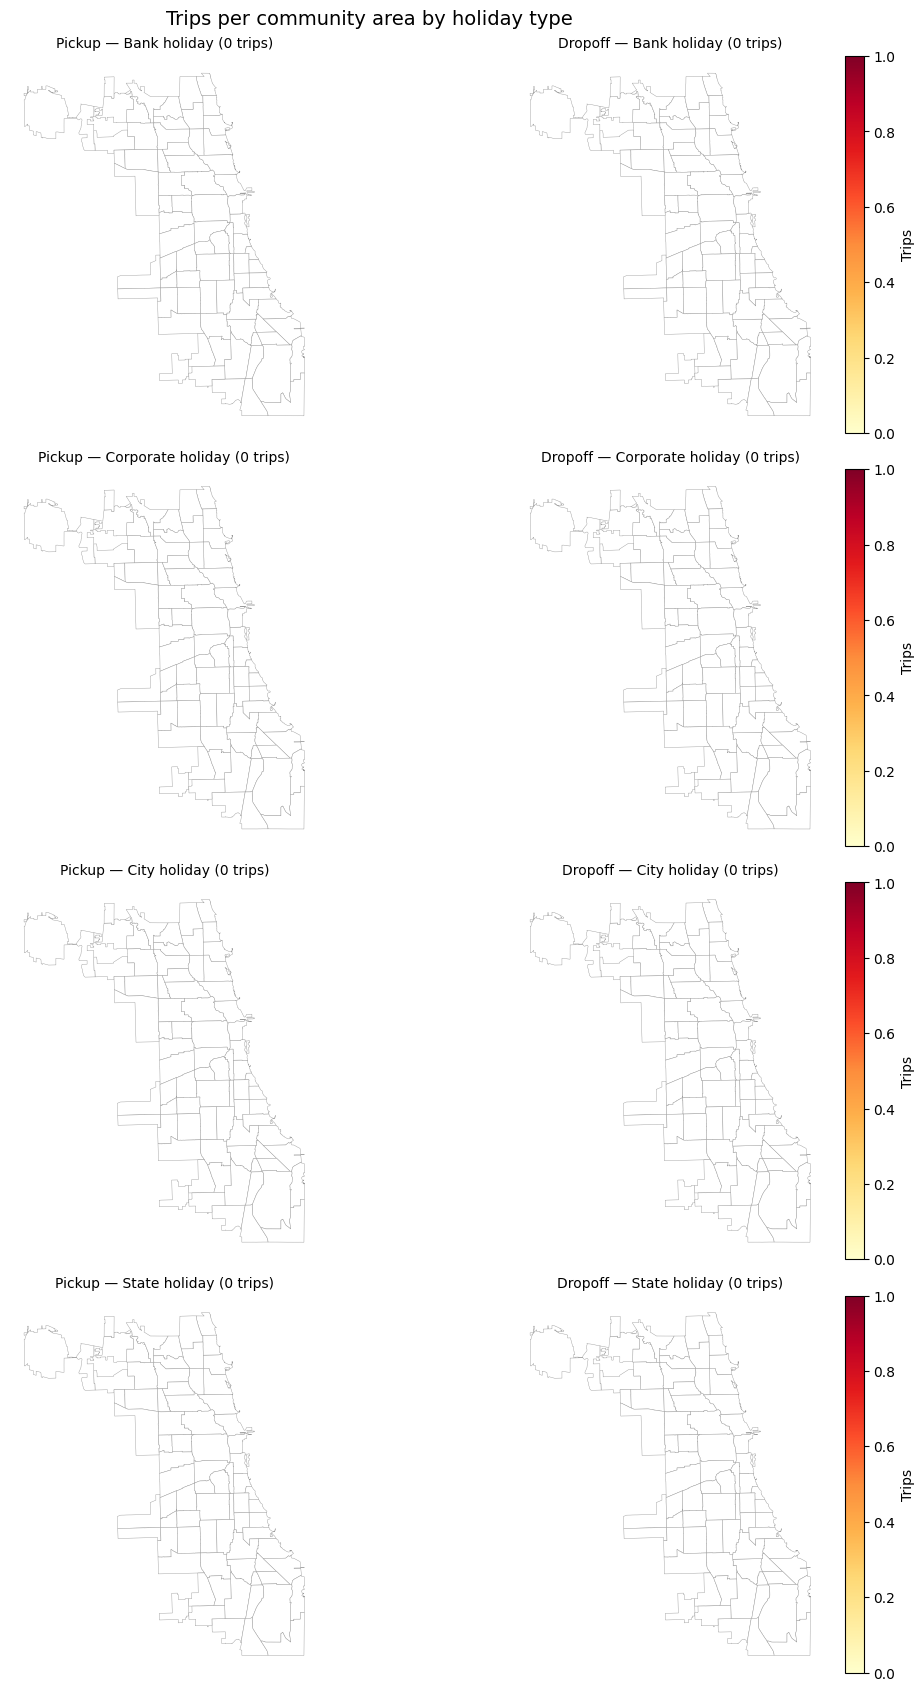

In [28]:
#| label: fig-holiday-demand
#| fig-cap: "Trips per community area by holiday type, pickup (left) vs dropoff (right); each row uses its own scale (holiday types differ greatly in volume). The demand geography is unchanged on holidays — the airport and downtown poles persist."
_HOLIDAY_TYPES = {
    "BankHoliday": "Bank holiday",
    "CorporateHoliday": "Corporate holiday",
    "CityHoliday": "City holiday",
    "StateHoliday": "State holiday",
}

_holiday_items = [
    (f"{name} ({(df[col] == 1).sum():,} trips)", df[df[col] == 1], df[df[col] == 1], None)
    for col, name in _HOLIDAY_TYPES.items()
]

plot_community_grid(
    _holiday_items,
    kind="count", cmap=COUNT_CMAP,
    suptitle="Trips per community area by holiday type",
    shared_scale=False, cbar_label="Trips",
    row_height=4.2,
)